# Entry Level Car Value GLM

#### This notebook builds a vehicle value depreciation factor GLM (Generalized Linear Model) for the Entry Level Car segment. The dependent variable is dep_factor = LIST_PRICE / MSRP — how much of the original MSRP the vehicle is currently listing at.

## Import packages & data

In [1]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns",25)
pd.set_option("display.max_rows",250)
pd.options.display.float_format = '{:,.2f}'.format

from IPython.display import display, HTML

display(HTML(data="""
<style>
    div#notebook-container    { width: 90%; }
    div#menubar-container     { width: 65%; }
    div#maintoolbar-container { width: 99%; }
</style>
"""))

import matplotlib.pyplot as plt

from __future__ import print_function
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets

from urllib.request import urlopen
import json

# import folium

# new packages to pip install
import random
from patsy import dmatrices
import statsmodels.api as sm

## Import Vehicle Value Model Functions

In [2]:
%run ./20250131_vehicle_value_model_functions.ipynb

## Data Prep
#### Reads Basic_Economy_Car.feather
#### Creates the dependent variable: dep_factor = LIST_PRICE / MSRP
#### Creates REC_CNT = 1 (record weight)
#### Renames SELLER_POSTAL_CODE → zip

In [3]:
# path = 'C:/Users/sarahmccracken/Box/Insurance Underwriting/Vehicle Scoring Products/VBS-D Enhanced Build 1.0/0040. Value  Factor GLM/VV Datasets/'
path = 'C:/Users/sarahmccracken/Desktop/datasets/VV Datasets/'
df = pd.read_feather(path + 'Entry_Level_Car.feather')
make_cat = pd.read_csv(path + 'Make_Category_Lookup.csv')

In [4]:
df['dep_factor'] = df['LIST_PRICE']/df['MSRP']
df['REC_CNT'] = 1

In [5]:
print(df.shape)
print(df['REC_CNT'].sum())

(3940703, 14)
3940703


In [6]:
df = df.rename(columns = {'SELLER_POSTAL_CODE': 'zip'})
df['zip'] = df['zip'].astype('int64')

In [7]:
[i for i in df]

['LIST_PRICE',
 'ODOMETER',
 'MSRP',
 'FIRST_TITLE_REG_STATE',
 'SECOND_TITLE_REG_STATE',
 'THIRD_TITLE_REG_STATE',
 'FOURTH_TITLE_REG_STATE',
 'FIFTHPLUS_TITLE_REG_STATE',
 'BODY_STYLE_SEGMENT_BODY_TYPE',
 'YEAR',
 'MAKE',
 'zip',
 'dep_factor',
 'REC_CNT']

In [8]:
df.head()

,LIST_PRICE,ODOMETER,MSRP,FIRST_TITLE_REG_STATE,SECOND_TITLE_REG_STATE,THIRD_TITLE_REG_STATE,FOURTH_TITLE_REG_STATE,FIFTHPLUS_TITLE_REG_STATE,BODY_STYLE_SEGMENT_BODY_TYPE,YEAR,MAKE,zip,dep_factor,REC_CNT
0,8900,74417,19500,CA,.,.,.,.,Entry Level (Car),2012,MINI,92078,0.46,1
1,10378,78152,21850,PA,.,.,.,.,Entry Level (Car),2007,MINI,22303,0.47,1
2,6341,107633,14550,OR,CA,.,.,.,Entry Level (Car),2008,SCION,95076,0.44,1
3,10000,10512,13590,CT,.,.,.,.,Entry Level (Car),2008,SMART,6790,0.74,1
4,7495,57587,14150,OK,.,.,.,.,Entry Level (Car),2010,NISSAN,73013,0.53,1


## Prep Odometer
#### Caps at 200K, creates odometer_band (rounds up to nearest 5K)

In [9]:
df['ODOMETER'] = df['ODOMETER'].clip(upper=200000)

In [10]:
df['odometer_band'] = np.ceil(df['ODOMETER'] / 5000) * 5000

In [11]:
df.head()

,LIST_PRICE,ODOMETER,MSRP,FIRST_TITLE_REG_STATE,SECOND_TITLE_REG_STATE,THIRD_TITLE_REG_STATE,FOURTH_TITLE_REG_STATE,FIFTHPLUS_TITLE_REG_STATE,BODY_STYLE_SEGMENT_BODY_TYPE,YEAR,MAKE,zip,dep_factor,REC_CNT,odometer_band
0,8900,74417,19500,CA,.,.,.,.,Entry Level (Car),2012,MINI,92078,0.46,1,"75,000.00"
1,10378,78152,21850,PA,.,.,.,.,Entry Level (Car),2007,MINI,22303,0.47,1,"80,000.00"
2,6341,107633,14550,OR,CA,.,.,.,Entry Level (Car),2008,SCION,95076,0.44,1,"110,000.00"
3,10000,10512,13590,CT,.,.,.,.,Entry Level (Car),2008,SMART,6790,0.74,1,"15,000.00"
4,7495,57587,14150,OK,.,.,.,.,Entry Level (Car),2010,NISSAN,73013,0.53,1,"60,000.00"


## Prep Make
#### Cleans make names (spaces/hyphens → underscores), then creates one binary dummy column per make (MAKE_HONDA, MAKE_TOYOTA, etc.)

In [12]:
make_counts = df['MAKE'].value_counts()
print(make_counts)

MAKE
NISSAN        773669
CHEVROLET     596628
MINI          587848
HYUNDAI       408258
FORD          336718
HONDA         320902
TOYOTA        270717
KIA           213832
FIAT          131407
MITSUBISHI     84459
SCION          83048
MAZDA          73148
SMART          49162
SUZUKI          8004
PONTIAC         2378
DAEWOO           344
GMC              179
FERRARI            2
Name: count, dtype: int64


In [13]:
df['MAKE'] = df['MAKE'].str.replace(' ', '_').str.replace('-', '_')

In [14]:
make_counts = df['MAKE'].value_counts()
print(make_counts)

MAKE
NISSAN        773669
CHEVROLET     596628
MINI          587848
HYUNDAI       408258
FORD          336718
HONDA         320902
TOYOTA        270717
KIA           213832
FIAT          131407
MITSUBISHI     84459
SCION          83048
MAZDA          73148
SMART          49162
SUZUKI          8004
PONTIAC         2378
DAEWOO           344
GMC              179
FERRARI            2
Name: count, dtype: int64


In [15]:
make_list = df['MAKE'].drop_duplicates().to_list()
make_list.sort()

for make in make_list:
    df['MAKE_' + make] = np.where(df['MAKE'] == make, True, False)
    
for i in [i for i in df.columns if 'MAKE_' in i]:
    print('+ ' + i)

+ MAKE_CHEVROLET
+ MAKE_DAEWOO
+ MAKE_FERRARI
+ MAKE_FIAT
+ MAKE_FORD
+ MAKE_GMC
+ MAKE_HONDA
+ MAKE_HYUNDAI
+ MAKE_KIA
+ MAKE_MAZDA
+ MAKE_MINI
+ MAKE_MITSUBISHI
+ MAKE_NISSAN
+ MAKE_PONTIAC
+ MAKE_SCION
+ MAKE_SMART
+ MAKE_SUZUKI
+ MAKE_TOYOTA


## Prep State
#### Coalesces up to five title registration state columns into a single STATE using the most recent non-null value (works backwards from FIFTHPLUS → FIRST). Keeps only the 50 US states, then creates binary dummy columns per state (STATE_NY, STATE_CA, etc.)

In [16]:
# First, replace periods with NaN for proper handling
state_columns = [
    'FIRST_TITLE_REG_STATE',
    'SECOND_TITLE_REG_STATE', 
    'THIRD_TITLE_REG_STATE',
    'FOURTH_TITLE_REG_STATE',
    'FIFTHPLUS_TITLE_REG_STATE'
]

# Replace '.' with NaN in state columns
for col in state_columns:
    df[col] = df[col].replace('.', pd.NA)

# Using coalesce-like behavior with fillna - work backwards from most recent
df['STATE'] = (
    df['FIFTHPLUS_TITLE_REG_STATE']
    .fillna(df['FOURTH_TITLE_REG_STATE'])
    .fillna(df['THIRD_TITLE_REG_STATE'])
    .fillna(df['SECOND_TITLE_REG_STATE'])
    .fillna(df['FIRST_TITLE_REG_STATE'])
)

# Handle multiple states in FIFTHPLUS column separated by pipe delimiter
df['STATE'] = df['STATE'].apply(
    lambda x: str(x).split('|')[0].strip() if pd.notna(x) else None
)

In [17]:
state_columns = [
    'FIRST_TITLE_REG_STATE',
    'SECOND_TITLE_REG_STATE', 
    'THIRD_TITLE_REG_STATE',
    'FOURTH_TITLE_REG_STATE',
    'FIFTHPLUS_TITLE_REG_STATE'
]

df = df.drop(columns = state_columns)

In [18]:
df = df.dropna()

In [19]:
df.shape

(3838054, 29)

In [20]:
states = df['STATE'].unique()
print(states)

['CA' 'PA' 'CT' 'OK' 'TX' 'VA' 'NY' 'ME' 'FL' 'SC' 'LA' 'GA' 'IL' 'NJ'
 'WA' 'MS' 'OH' 'NC' 'OR' 'MA' 'KS' 'AZ' 'MI' 'MN' 'IA' 'MD' 'WI' 'TN'
 'MO' 'IN' 'HI' 'WV' 'SD' 'CO' 'AR' 'KY' 'AL' 'ID' 'ND' 'NV' 'RI' 'UT'
 'MT' 'NH' 'DC' 'NE' 'NM' 'DE' 'BC' 'AK' 'VT' 'PR' 'WY' 'ON' 'QC' 'AB'
 'SK' 'MB' 'NS' 'NB' 'NL' 'PE']


In [21]:
# Keep only US States
print(df.shape)
us_states = [
    'NY', 'CA', 'CO', 'PA', 'VA', 'WA', 'WI', 'NJ', 'NC', 'MA',
    'AR', 'AL', 'MS', 'FL', 'OH', 'TX', 'MI', 'OK', 'OR', 'GA',
    'IL', 'TN', 'NV', 'AZ', 'SC', 'MO', 'NM', 'CT', 'MD', 'KS',
    'HI', 'MN', 'RI', 'UT', 'KY', 'LA', 'VT', 'NE', 'IA', 'NH',
    'ME', 'MT', 'WV', 'AK', 'IN', 'ID', 'DE', 'ND', 'SD', 'WY'
]

# Replace 'state_column' with the actual name of your state column
df = df[df['STATE'].isin(us_states)]
print(df.shape)

(3838054, 29)
(3828704, 29)


In [22]:
state_counts = df['STATE'].value_counts()
print(state_counts)

STATE
CA    504707
FL    415152
TX    319511
PA    166677
AZ    158782
OH    156957
IL    137827
NY    128587
VA    109687
GA    108555
NC    103498
NJ     99718
WA     98967
TN     92372
MI     87456
MD     78868
MA     75077
IN     67632
OK     64821
CO     62180
MO     56009
OR     53840
NV     53256
SC     51101
WI     49285
AL     43563
MN     41307
KY     39188
CT     38292
LA     35001
UT     34855
KS     30610
HI     27114
IA     25549
NM     23532
AR     22718
NH     20546
MS     19395
MT     17752
WV     17447
NE     16457
ID     15563
ME     12704
RI     11759
DE      8911
VT      8151
AK      6081
SD      4991
ND      3482
WY      3214
Name: count, dtype: int64


In [23]:
state_list = df['STATE'].drop_duplicates().to_list()
state_list.sort()

for state in state_list:
    df['STATE_' + state] = np.where(df['STATE'] == state, True, False)
    
for i in [i for i in df.columns if 'STATE_' in i]:
    print('+ ' + i)

+ STATE_AK
+ STATE_AL
+ STATE_AR
+ STATE_AZ
+ STATE_CA
+ STATE_CO
+ STATE_CT
+ STATE_DE
+ STATE_FL
+ STATE_GA
+ STATE_HI
+ STATE_IA
+ STATE_ID
+ STATE_IL
+ STATE_IN
+ STATE_KS
+ STATE_KY
+ STATE_LA
+ STATE_MA
+ STATE_MD
+ STATE_ME
+ STATE_MI
+ STATE_MN
+ STATE_MO
+ STATE_MS
+ STATE_MT
+ STATE_NC
+ STATE_ND
+ STATE_NE
+ STATE_NH
+ STATE_NJ
+ STATE_NM
+ STATE_NV
+ STATE_NY
+ STATE_OH
+ STATE_OK
+ STATE_OR
+ STATE_PA
+ STATE_RI
+ STATE_SC
+ STATE_SD
+ STATE_TN
+ STATE_TX
+ STATE_UT
+ STATE_VA
+ STATE_VT
+ STATE_WA
+ STATE_WI
+ STATE_WV
+ STATE_WY


## Append Geo data
#### Reads a zip-level geography file with geo_pop_density
#### Calculates geo_pop_density_ntile: a percentile (0–100) weighted by observation count — so it reflects the distribution of actual records, not just zips
#### Merges onto the main dataset; missing zips fall back to state-average ntile, then 50 as a last resort

In [24]:
geo_path = 'C:/Users/sarahmccracken/Box/Insurance Underwriting/Vehicle Scoring Products/VBS-D Enhanced Build 1.0/0010. Data Preparation/'
geo = pd.read_csv(geo_path + 'geo_2017_2023_20260128.csv')

geo = geo.loc[geo['census_year'] == 2023]

geo = geo[(['zip','geo_pop_density'])]

geo = geo.loc[geo['geo_pop_density'].isna() == False]

print(geo.shape)
geo.head()

(28582, 2)


,zip,geo_pop_density
14,601,259.56
19,602,"1,236.85"
34,606,122.59
39,610,684.54
42,611,142.98


In [25]:
a = df.groupby(['zip']).agg({'REC_CNT': 'count'}).reset_index()

In [26]:
a.head(50)

,zip,REC_CNT
0,612,2
1,692,1
2,725,12
3,918,8
4,919,4
5,920,2
6,927,1
7,929,1
8,959,1
9,969,3


In [27]:
print(geo.shape)
geo = geo.merge(a, how = 'left')
print(geo.shape)

geo.sort_values(by = 'geo_pop_density', inplace = True)

geo['cumsum'] = geo['REC_CNT'].cumsum()

geo['geo_pop_density_ntile'] = round(geo['cumsum']/geo['cumsum'].max(),2)*100

geo.head()

(28582, 2)
(28582, 3)


,zip,geo_pop_density,REC_CNT,cumsum,geo_pop_density_ntile
9585,35615,0.00,NaN,NaN,NaN
23360,77341,0.00,NaN,NaN,NaN
23361,77342,0.00,NaN,NaN,NaN
23375,77368,0.00,NaN,NaN,NaN
7486,28019,0.00,NaN,NaN,NaN


In [28]:
geo = geo[(['zip','geo_pop_density_ntile'])]

In [29]:
df = df.merge(geo, how = 'left')

In [30]:
df.shape

(3828704, 80)

In [31]:
df.head()

,LIST_PRICE,ODOMETER,MSRP,BODY_STYLE_SEGMENT_BODY_TYPE,YEAR,MAKE,zip,dep_factor,REC_CNT,odometer_band,MAKE_CHEVROLET,MAKE_DAEWOO,MAKE_FERRARI,MAKE_FIAT,MAKE_FORD,MAKE_GMC,MAKE_HONDA,MAKE_HYUNDAI,MAKE_KIA,MAKE_MAZDA,MAKE_MINI,MAKE_MITSUBISHI,MAKE_NISSAN,MAKE_PONTIAC,MAKE_SCION,MAKE_SMART,MAKE_SUZUKI,MAKE_TOYOTA,STATE,STATE_AK,STATE_AL,STATE_AR,STATE_AZ,STATE_CA,STATE_CO,STATE_CT,STATE_DE,STATE_FL,STATE_GA,STATE_HI,STATE_IA,STATE_ID,STATE_IL,STATE_IN,STATE_KS,STATE_KY,STATE_LA,STATE_MA,STATE_MD,STATE_ME,STATE_MI,STATE_MN,STATE_MO,STATE_MS,STATE_MT,STATE_NC,STATE_ND,STATE_NE,STATE_NH,STATE_NJ,STATE_NM,STATE_NV,STATE_NY,STATE_OH,STATE_OK,STATE_OR,STATE_PA,STATE_RI,STATE_SC,STATE_SD,STATE_TN,STATE_TX,STATE_UT,STATE_VA,STATE_VT,STATE_WA,STATE_WI,STATE_WV,STATE_WY,geo_pop_density_ntile
0,8900,74417,19500,Entry Level (Car),2012,MINI,92078,0.46,1,"75,000.00",False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,CA,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,NaN
1,10378,78152,21850,Entry Level (Car),2007,MINI,22303,0.47,1,"80,000.00",False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,PA,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,95.00
2,6341,107633,14550,Entry Level (Car),2008,SCION,95076,0.44,1,"110,000.00",False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,CA,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,NaN
3,10000,10512,13590,Entry Level (Car),2008,SMART,6790,0.74,1,"15,000.00",False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,CT,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,NaN
4,7495,57587,14150,Entry Level (Car),2010,NISSAN,73013,0.53,1,"60,000.00",False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,OK,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,47.00


In [32]:
gpdn_default_state = df.groupby(['STATE']).agg({'geo_pop_density_ntile': 'mean'}).reset_index()

gpdn_default_state.rename(columns = {'geo_pop_density_ntile': 'geo_pop_density_ntile_state_default'}, inplace = True)

gpdn_default_state['geo_pop_density_ntile_state_default'] = round(gpdn_default_state['geo_pop_density_ntile_state_default'],0)

gpdn_default_state

,STATE,geo_pop_density_ntile_state_default
0,AK,52.00
1,AL,30.00
2,AR,30.00
3,AZ,66.00
4,CA,65.00
5,CO,59.00
6,CT,47.00
7,DE,41.00
8,FL,53.00
9,GA,40.00


In [33]:
print(df.shape)
df = df.merge(gpdn_default_state, how = 'left')
print(df.shape)

df['geo_pop_density_ntile'] = df['geo_pop_density_ntile'].fillna(df['geo_pop_density_ntile_state_default']).fillna(50)

del df['geo_pop_density_ntile_state_default']

df.head()

(3828704, 80)
(3828704, 81)


,LIST_PRICE,ODOMETER,MSRP,BODY_STYLE_SEGMENT_BODY_TYPE,YEAR,MAKE,zip,dep_factor,REC_CNT,odometer_band,MAKE_CHEVROLET,MAKE_DAEWOO,MAKE_FERRARI,MAKE_FIAT,MAKE_FORD,MAKE_GMC,MAKE_HONDA,MAKE_HYUNDAI,MAKE_KIA,MAKE_MAZDA,MAKE_MINI,MAKE_MITSUBISHI,MAKE_NISSAN,MAKE_PONTIAC,MAKE_SCION,MAKE_SMART,MAKE_SUZUKI,MAKE_TOYOTA,STATE,STATE_AK,STATE_AL,STATE_AR,STATE_AZ,STATE_CA,STATE_CO,STATE_CT,STATE_DE,STATE_FL,STATE_GA,STATE_HI,STATE_IA,STATE_ID,STATE_IL,STATE_IN,STATE_KS,STATE_KY,STATE_LA,STATE_MA,STATE_MD,STATE_ME,STATE_MI,STATE_MN,STATE_MO,STATE_MS,STATE_MT,STATE_NC,STATE_ND,STATE_NE,STATE_NH,STATE_NJ,STATE_NM,STATE_NV,STATE_NY,STATE_OH,STATE_OK,STATE_OR,STATE_PA,STATE_RI,STATE_SC,STATE_SD,STATE_TN,STATE_TX,STATE_UT,STATE_VA,STATE_VT,STATE_WA,STATE_WI,STATE_WV,STATE_WY,geo_pop_density_ntile
0,8900,74417,19500,Entry Level (Car),2012,MINI,92078,0.46,1,"75,000.00",False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,CA,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,65.00
1,10378,78152,21850,Entry Level (Car),2007,MINI,22303,0.47,1,"80,000.00",False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,PA,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,95.00
2,6341,107633,14550,Entry Level (Car),2008,SCION,95076,0.44,1,"110,000.00",False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,CA,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,65.00
3,10000,10512,13590,Entry Level (Car),2008,SMART,6790,0.74,1,"15,000.00",False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,CT,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,47.00
4,7495,57587,14150,Entry Level (Car),2010,NISSAN,73013,0.53,1,"60,000.00",False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,OK,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,47.00


## Prep Vehicle Age and compare to what is already in the data
#### I don't trust the Vehicle Age variable in the dataset already. Calculating it on my own to compare. 
#### CALC_VEH_AGE = 2026 - YEAR

In [34]:
df['YEAR'] = df['YEAR'].astype(int)

df['CALC_VEH_AGE'] = 2026 - df['YEAR']

In [35]:
calc_veh_age_counts = df['CALC_VEH_AGE'].value_counts()
print(calc_veh_age_counts)

CALC_VEH_AGE
11    393499
14    380105
13    370923
10    346912
9     325514
12    322967
15    253579
7     227176
8     219888
16    177205
17    177150
18    137632
6     117448
19     99472
5      88789
20     44823
21     32749
4      27822
22     19858
3      19524
23     15213
2      10375
24     10246
25      4934
26      2954
1       1126
27       508
28       313
Name: count, dtype: int64


## Split data into trait, test, holdout
#### Splits the data reproducibly (seed=42) into:
#### Train: 40%, Test: 30%, Holdout: 30%

In [37]:
min_threshold = 1e-4  
max_threshold = 2 

# Apply thresholds
df = df.copy()
df['dep_factor'] = df['dep_factor'].clip(lower=min_threshold, upper=max_threshold)

print(f"After capping:")
print(f"  Min: {df['dep_factor'].min():.6f}")
print(f"  Max: {df['dep_factor'].max():.6f}")
print(f"  Values changed to min: {(df['dep_factor'] < min_threshold).sum()}")
print(f"  Values changed to max: {(df['dep_factor'] > max_threshold).sum()}")

After capping:
  Min: 0.000100
  Max: 2.000000
  Values changed to min: 0
  Values changed to max: 0


In [38]:
[i for i in df]

['LIST_PRICE',
 'ODOMETER',
 'MSRP',
 'BODY_STYLE_SEGMENT_BODY_TYPE',
 'YEAR',
 'MAKE',
 'zip',
 'dep_factor',
 'REC_CNT',
 'odometer_band',
 'MAKE_CHEVROLET',
 'MAKE_DAEWOO',
 'MAKE_FERRARI',
 'MAKE_FIAT',
 'MAKE_FORD',
 'MAKE_GMC',
 'MAKE_HONDA',
 'MAKE_HYUNDAI',
 'MAKE_KIA',
 'MAKE_MAZDA',
 'MAKE_MINI',
 'MAKE_MITSUBISHI',
 'MAKE_NISSAN',
 'MAKE_PONTIAC',
 'MAKE_SCION',
 'MAKE_SMART',
 'MAKE_SUZUKI',
 'MAKE_TOYOTA',
 'STATE',
 'STATE_AK',
 'STATE_AL',
 'STATE_AR',
 'STATE_AZ',
 'STATE_CA',
 'STATE_CO',
 'STATE_CT',
 'STATE_DE',
 'STATE_FL',
 'STATE_GA',
 'STATE_HI',
 'STATE_IA',
 'STATE_ID',
 'STATE_IL',
 'STATE_IN',
 'STATE_KS',
 'STATE_KY',
 'STATE_LA',
 'STATE_MA',
 'STATE_MD',
 'STATE_ME',
 'STATE_MI',
 'STATE_MN',
 'STATE_MO',
 'STATE_MS',
 'STATE_MT',
 'STATE_NC',
 'STATE_ND',
 'STATE_NE',
 'STATE_NH',
 'STATE_NJ',
 'STATE_NM',
 'STATE_NV',
 'STATE_NY',
 'STATE_OH',
 'STATE_OK',
 'STATE_OR',
 'STATE_PA',
 'STATE_RI',
 'STATE_SC',
 'STATE_SD',
 'STATE_TN',
 'STATE_TX',
 'STATE_

In [39]:
print(df.shape)
df = df[~np.isinf(df['dep_factor'])].copy()
print(df.shape)

(3828704, 81)
(3828704, 81)


In [40]:
def tt_split(data, train_size, test_size):
    np.random.seed(seed=42)
    data['rand'] = np.random.randint(1, 101, data.shape[0]) / 100
    data1_train = data.loc[data['rand'] <= train_size].copy()
    data1_test = data.loc[(data['rand'] > train_size) & (data['rand'] <= train_size + test_size)].copy()
    data1_holdout = data.loc[data['rand'] > train_size + test_size].copy()
    del data1_train['rand']
    del data1_test['rand']
    del data1_holdout['rand']
    return data1_train, data1_test, data1_holdout

d_train, d_test, d_holdout = tt_split(df, .40, .30)
print(d_train.shape, d_test.shape, d_holdout.shape)

(1531979, 81) (1147742, 81) (1148983, 81)


In [41]:
print(d_train.shape)
print(d_train['REC_CNT'].sum())

(1531979, 81)
1531979


In [42]:
print(d_test.shape)
print(d_test['REC_CNT'].sum())

(1147742, 81)
1147742


In [43]:
print(d_holdout.shape)
print(d_holdout['REC_CNT'].sum())

(1148983, 81)
1148983


In [44]:
[i for i in d_train]

['LIST_PRICE',
 'ODOMETER',
 'MSRP',
 'BODY_STYLE_SEGMENT_BODY_TYPE',
 'YEAR',
 'MAKE',
 'zip',
 'dep_factor',
 'REC_CNT',
 'odometer_band',
 'MAKE_CHEVROLET',
 'MAKE_DAEWOO',
 'MAKE_FERRARI',
 'MAKE_FIAT',
 'MAKE_FORD',
 'MAKE_GMC',
 'MAKE_HONDA',
 'MAKE_HYUNDAI',
 'MAKE_KIA',
 'MAKE_MAZDA',
 'MAKE_MINI',
 'MAKE_MITSUBISHI',
 'MAKE_NISSAN',
 'MAKE_PONTIAC',
 'MAKE_SCION',
 'MAKE_SMART',
 'MAKE_SUZUKI',
 'MAKE_TOYOTA',
 'STATE',
 'STATE_AK',
 'STATE_AL',
 'STATE_AR',
 'STATE_AZ',
 'STATE_CA',
 'STATE_CO',
 'STATE_CT',
 'STATE_DE',
 'STATE_FL',
 'STATE_GA',
 'STATE_HI',
 'STATE_IA',
 'STATE_ID',
 'STATE_IL',
 'STATE_IN',
 'STATE_KS',
 'STATE_KY',
 'STATE_LA',
 'STATE_MA',
 'STATE_MD',
 'STATE_ME',
 'STATE_MI',
 'STATE_MN',
 'STATE_MO',
 'STATE_MS',
 'STATE_MT',
 'STATE_NC',
 'STATE_ND',
 'STATE_NE',
 'STATE_NH',
 'STATE_NJ',
 'STATE_NM',
 'STATE_NV',
 'STATE_NY',
 'STATE_OH',
 'STATE_OK',
 'STATE_OR',
 'STATE_PA',
 'STATE_RI',
 'STATE_SC',
 'STATE_SD',
 'STATE_TN',
 'STATE_TX',
 'STATE_

## Final Model Results

In [45]:
import gc, os, tempfile

# 1. Free all large objects that are no longer needed
for _v in ['df', 'geo', 'a', 'gpdn_default_state', 'make_cat',
           'make_counts', 'calc_veh_age_counts', 'state_counts', 'states',
           'X_train', 'y_train', 'glm', 'glm_results', 'out_df']:
    if _v in globals():
        del globals()[_v]
gc.collect()

# 2. Save d_test and d_holdout to temp files (if still in memory) — reload after fitting
_temp_dir = tempfile.gettempdir()
if 'd_test' in globals():
    d_test.to_feather(os.path.join(_temp_dir, '_vv_d_test.feather'))
    d_holdout.to_feather(os.path.join(_temp_dir, '_vv_d_holdout.feather'))
    del d_test, d_holdout
    gc.collect()
    print(f"Saved d_test and d_holdout to {_temp_dir}")
else:
    print("d_test/d_holdout already saved or not in memory")

print(f"Memory freed. d_train shape: {d_train.shape}")

Saved d_test and d_holdout to C:\Users\SARAHM~1\AppData\Local\Temp
Memory freed. d_train shape: (1531979, 81)


In [47]:
formula = """
    dep_factor ~ ODOMETER 
    + geo_pop_density_ntile 
    + CALC_VEH_AGE 
    + STATE_AL 
    + STATE_AR 
    + STATE_AZ 
    + STATE_CO 
    + STATE_CT 
    + STATE_FL 
    + STATE_GA 
    + STATE_HI 
    + STATE_IL 
    + STATE_KS 
    + STATE_KY 
    + STATE_LA 
    + STATE_MA 
    + STATE_MI 
    + STATE_MN 
    + STATE_MO 
    + STATE_MS 
    + STATE_NC 
    + STATE_ND 
    + STATE_NH 
    + STATE_NJ 
    + STATE_NM 
    + STATE_NV 
    + STATE_NY 
    + STATE_OH 
    + STATE_OK 
    + STATE_PA 
    + STATE_SC 
    + STATE_TN 
    + STATE_TX 
    + STATE_VT 
    + STATE_WA 
    + STATE_WI 
    + STATE_WV 
    + MAKE_DAEWOO 
    + MAKE_FIAT 
    + MAKE_FORD 
    + MAKE_HONDA 
    + MAKE_HYUNDAI 
    + MAKE_KIA 
    + MAKE_NISSAN 
    + MAKE_PONTIAC 
    + MAKE_SCION 
    + MAKE_SMART 
    + MAKE_SUZUKI 
    + MAKE_TOYOTA 
"""
FINAL_FIT_SIZE = 2_000_000
if len(d_train) > FINAL_FIT_SIZE:
    d_fit = d_train.sample(n=FINAL_FIT_SIZE, random_state=42)
    print(f"Fitting on {FINAL_FIT_SIZE:,}-row sample (d_train has {len(d_train):,} rows)")
else:
    d_fit = d_train

easy_glm_specify_construction(formula, d_fit, 'REC_CNT')
print('Rebase Factor =' + str(rebase_factor))

                 Generalized Linear Model Regression Results                  
Dep. Variable:             dep_factor   No. Observations:              1531979
Model:                            GLM   Df Residuals:                  1531929
Model Family:                   Gamma   Df Model:                           49
Link Function:                    Log   Scale:                        0.062727
Method:                          IRLS   Log-Likelihood:             3.4410e+05
Date:                Wed, 13 May 2026   Deviance:                   1.2884e+05
Time:                        12:41:20   Pearson chi2:                 9.61e+04
No. Iterations:                    30   Pseudo R-squ. (CS):             0.5730
Covariance Type:            nonrobust                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 0.01

In [48]:
# Reload d_test and d_holdout from temp files
import tempfile, os
_temp_dir = tempfile.gettempdir()
d_test = pd.read_feather(os.path.join(_temp_dir, '_vv_d_test.feather'))
d_holdout = pd.read_feather(os.path.join(_temp_dir, '_vv_d_holdout.feather'))
print(f"Reloaded d_test {d_test.shape}, d_holdout {d_holdout.shape}")

Reloaded d_test (1147742, 81), d_holdout (1148983, 81)


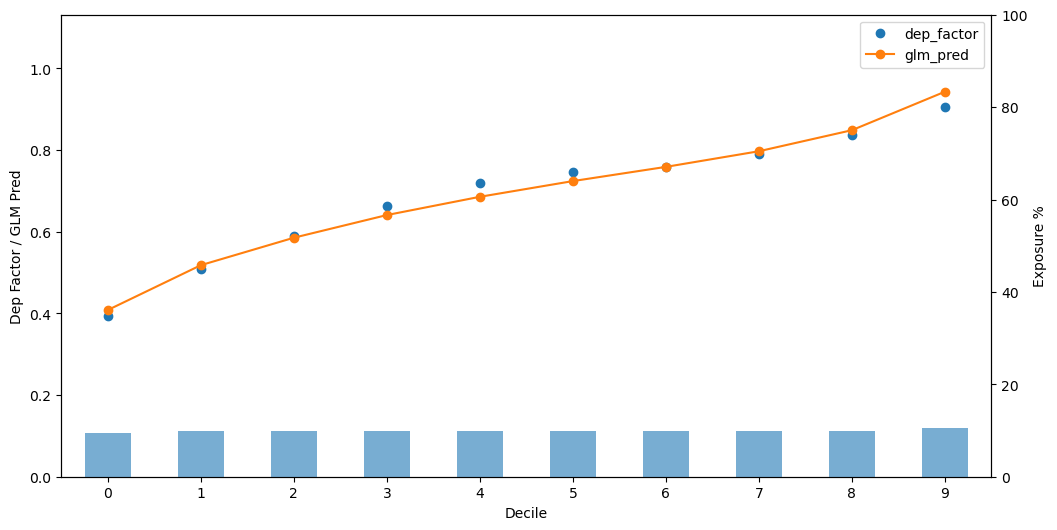

   decile  REC_CNT  dep_factor  glm_pred  weight_percent
0    1.00   145538        0.39      0.41            9.50
1    2.00   153197        0.51      0.52           10.00
2    3.00   153198        0.59      0.59           10.00
3    4.00   153198        0.66      0.64           10.00
4    5.00   153198        0.72      0.69           10.00
5    6.00   153198        0.75      0.72           10.00
6    7.00   153198        0.76      0.76           10.00
7    8.00   153198        0.79      0.80           10.00
8    9.00   153198        0.84      0.85           10.00
9   10.00   160858        0.90      0.94           10.50


In [49]:
lift_chart(d_train,'REC_CNT',10)

Data contains 1,531,979 records. Sampling 50,000 records for plotting.


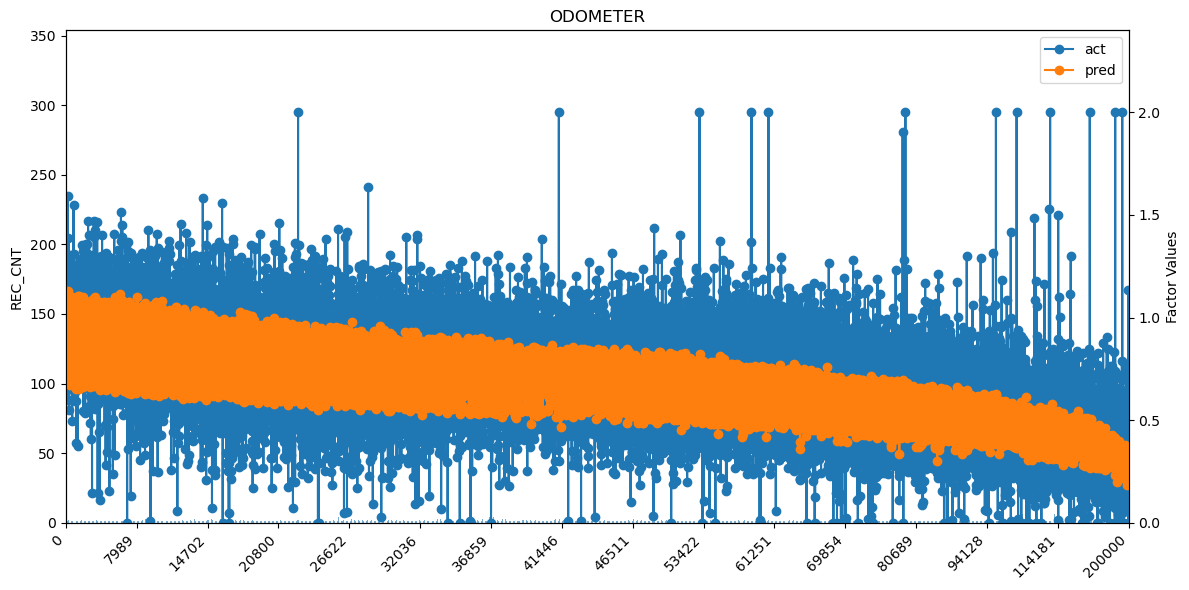

In [50]:
resid_plot(d_train,'ODOMETER','REC_CNT')

Data contains 1,531,979 records. Sampling 50,000 records for plotting.


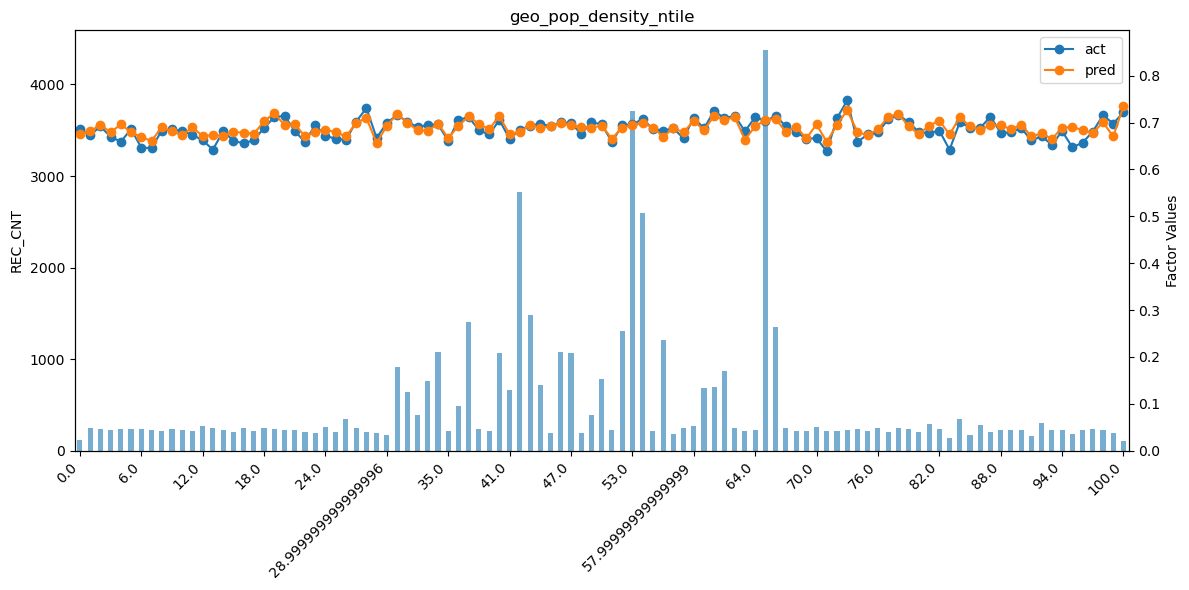

In [51]:
resid_plot(d_train,'geo_pop_density_ntile','REC_CNT')

Data contains 1,531,979 records. Sampling 50,000 records for plotting.


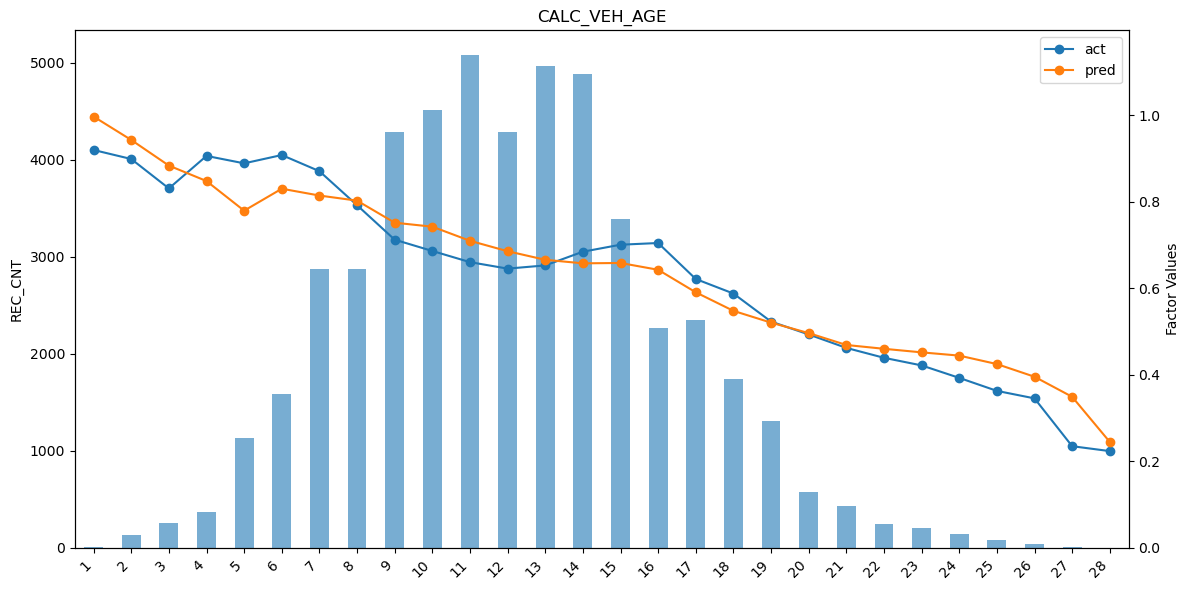

In [52]:
resid_plot(d_train,'CALC_VEH_AGE','REC_CNT')